In [ ]:
# Caminho do arquivo com dados brutos
path = '../data/hospital_patients_real_world.csv'
import pandas as pd
import seaborn as sns

In [ ]:
# Ler os dados do dataset e converte para DataFrame
df = pd.read_csv(path)
df.head(100)

In [ ]:
# Informações das colunas - Quant. não nulo e o tipo de dado das colunas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      5000 non-null   str    
 1   Age            4650 non-null   float64
 2   Gender         4650 non-null   str    
 3   Diagnosis      4650 non-null   str    
 4   AdmissionDate  5000 non-null   str    
 5   DischargeDate  5000 non-null   str    
 6   HospitalID     5000 non-null   str    
dtypes: float64(1), str(6)
memory usage: 273.6 KB


In [ ]:
# Quant. de nulos por coluna
df.isnull().sum()

PatientID          0
Age              350
Gender           350
Diagnosis        350
AdmissionDate      0
DischargeDate      0
HospitalID         0
dtype: int64

In [ ]:
# Verifica se existem linhas completamente nulas
df.isna().all(axis=1).any()
# Comentário: Não existem linhas totalmente nulas no DataFrame

np.False_

In [ ]:
# Verifica os valores únicos da coluna Gender
df['Gender'].unique()
# Comentário: Possui nan que podem ser agregadas a categoria Unknown

<StringArray>
['Other', 'Unknown', 'Female', 'Male', nan]
Length: 5, dtype: str

In [ ]:
# Verifdica a quantidade de dados por categoria na coluna Gender para analisar numero de Unknown
df['Gender'].value_counts()
# Comentário: Grande volume de Unknown na coluna Gender

Gender
Other      1223
Unknown    1163
Female     1153
Male       1111
Name: count, dtype: int64

In [ ]:
# Verifica os valores únicos da coluna Diagnosis
df['Diagnosis'].unique()
# Comentário: Existem palavras em caixa alta que já existem em caixa baixa, contando como distintas

<StringArray>
[  'Myocardial Infarction',               'Pneumonia',
               'Influenza',        'Acute Bronchitis',
         'Type 2 Diabetes',         'Gastroenteritis',
 'Urinary Tract Infection',          'Diverticulitis',
          'Cholelithiasis',          'CHOLELITHIASIS',
            'HYPERTENSION',  'Chronic Kidney Disease',
     'Atrial Fibrillation',                  'Asthma',
                       nan,          'Osteoarthritis',
            'Hypertension', 'URINARY TRACT INFECTION',
               'INFLUENZA',         'GASTROENTERITIS',
         'TYPE 2 DIABETES',                  'ASTHMA',
               'PNEUMONIA',          'DIVERTICULITIS',
        'ACUTE BRONCHITIS',  'CHRONIC KIDNEY DISEASE',
     'ATRIAL FIBRILLATION',   'MYOCARDIAL INFARCTION',
          'OSTEOARTHRITIS']
Length: 29, dtype: str

<Axes: ylabel='Age'>

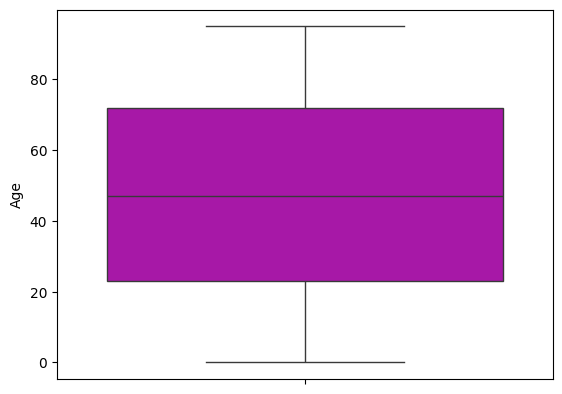

In [ ]:
# Gráfico boxplot para verificar possíveis outliers na coluna Age - Para decidir qual método de preenchimento dos valores nulos
sns.boxplot(df.Age, color = 'm')
# Comentário: Não possui outliers, podendo utilizar a média ou a mediana

In [ ]:

# Verifica se há datas de saída antes das datas de entrada, sendo uma incosistência
invalid = df['AdmissionDate'] > df['DischargeDate']
df_invalid = df[invalid]
# Comentário: Existem datas de alta antes de datas de entrada no hospital

In [ ]:
# Verifica de períodos inválidos para ajudar na tomada de decisão
percentual = len(df_invalid) / len(df) * 100
percentual

# Comentário: Cerca de 3% dos dados estão com as datas inconsistente, como o número não é muito grande pode-se tratar ou criar coluna auxiliar

3.0